# Free Call Option + Dynamic Delta Hedge — v4 (Pure Gamma T2)

## Strategy Overview

Same as v2 but **Tranche 2 upslope is removed**. Instead of ramping short up from 0→20-D as price falls into 50–65% OTM (anti-gamma), we sit flat at 0 through the gap zone, then step to 20-D at exactly 65% OTM and scale linearly off to 0 at 80% OTM.

**Why**: the upslope in v2 was anti-gamma — it added short as price fell, meaning oscillations in that zone bled money. The downslope (65–80%) is genuine gamma scalp. v4 keeps only the gamma-positive half of T2.

---

## Hedge Sizing Rules

| OTM% | Short Size | Zone |
|---|---|---|
| < 0% (ITM) | **60-D** flat | ITM |
| 0% (ATM) | **60-D** | Tranche 1 top |
| 20% | **50-D** ← inception | Tranche 1 |
| 50% | **0-D** | Gap |
| 50–65% | **0-D** | Gap (no position) |
| 65% | **20-D** step-on | Tranche 2 start |
| 80% | **0-D** | Tranche 2 end |
| > 80% | **0-D** | Dead zone |

**Key difference from v2**: no upslope ramp. Short jumps from 0 to 20-D at 65% OTM (small discontinuity), then declines. Every oscillation in T2 is now gamma-positive: more short when price is higher in the zone, less when lower.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

# ── Parameters ────────────────────────────────────────────────────────────────
SIGMA     = 0.75
R         = 0.05
T0        = 4.0
OTM_START = 0.20

# Tranche 1
SHORT_AT_START = 0.50
SHORT_AT_ATM   = 0.60
OTM_FLOOR_T1   = 0.50

# Tranche 2 — downslope only
OTM_T2_PEAK    = 0.65   # step-on point
OTM_T2_END     = 0.80
SHORT_T2_PEAK  = 0.20

In [2]:
# ── Strategy Functions ─────────────────────────────────────────────────────────

def bs_delta(S, K, T, r=R, sigma=SIGMA):
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    return norm.cdf(d1)


def target_short_v1(S, K):
    """v1: single tranche, no T2."""
    otm = (K - S) / S
    if otm > 0.50:    return 0.0
    elif otm > 0.20:  return 0.5 * (0.50 - otm) / 0.30
    elif otm >= 0.0:  return 0.5 + 0.1 * (0.20 - otm) / 0.20
    else:             return 0.60


def target_short_v2(S, K):
    """v2: T2 with upslope (50→65% OTM ramp up)."""
    otm = (K - S) / S
    if otm <= 0.0:    return 0.60
    elif otm <= 0.20: return 0.5 + 0.1 * (0.20 - otm) / 0.20
    elif otm <= 0.50: return 0.5 * (0.50 - otm) / 0.30
    elif otm <= 0.65: return 0.20 * (otm - 0.50) / 0.15
    elif otm <= 0.80: return 0.20 * (0.80 - otm) / 0.15
    else:             return 0.0


def target_short_v4(S, K):
    """
    v4: T2 downslope only. Gap 50–65% OTM (0 short),
    step to 20-D at 65%, linear decay to 0 at 80%.
    """
    otm = (K - S) / S
    if otm <= 0.0:
        return SHORT_AT_ATM
    elif otm <= OTM_START:
        return SHORT_AT_START + (SHORT_AT_ATM - SHORT_AT_START) * (OTM_START - otm) / OTM_START
    elif otm <= OTM_FLOOR_T1:
        return SHORT_AT_START * (OTM_FLOOR_T1 - otm) / (OTM_FLOOR_T1 - OTM_START)
    elif otm < OTM_T2_PEAK:
        # Gap: no position 50–65%
        return 0.0
    elif otm <= OTM_T2_END:
        # Downslope only: 65% → 80% OTM, linear 20-D → 0
        return SHORT_T2_PEAK * (OTM_T2_END - otm) / (OTM_T2_END - OTM_T2_PEAK)
    else:
        return 0.0


def run_backtest(prices, fn):
    S0      = prices[0]
    K       = S0 * (1 + OTM_START)
    records = []
    cum_pnl = 0.0
    short   = fn(S0, K)

    for i in range(1, len(prices)):
        P_prev = prices[i - 1]
        P_curr = prices[i]
        T      = T0 - i / 365.0

        day_pnl  = short * (P_prev - P_curr)
        cum_pnl += day_pnl

        otm   = (K - P_curr) / P_curr
        bs_d  = bs_delta(P_curr, K, T)
        net_d = bs_d - short

        records.append({
            'day': i, 'price': P_curr, 'otm_pct': otm * 100,
            'short': short, 'bs_delta': bs_d, 'net_delta': net_d,
            'day_pnl': day_pnl, 'cum_pnl': cum_pnl,
        })
        short = fn(P_curr, K)

    option_payoff = max(0.0, prices[-1] - K)
    total_pnl     = cum_pnl + option_payoff
    summary = {
        'strike': K, 'start_price': S0, 'end_price': prices[-1],
        'hedge_pnl': cum_pnl, 'option_payoff': option_payoff,
        'total_pnl': total_pnl,
        'pnl_pct': total_pnl / S0 * 100,
        'eth_return_pct': (prices[-1] / S0 - 1) * 100,
    }
    return records, summary

In [3]:
# ── Price Data (CoinGecko daily, Jan 13 – Apr 13 2026) ────────────────────────

prices_3m = [
    3319.935, 3356.496, 3318.204, 3296.063, 3306.871, 3284.319, 3185.664,
    2935.623, 2976.049, 2948.278, 2950.913, 2949.197, 2814.185, 2927.837,
    3021.092, 3006.807, 2818.818, 2702.408, 2443.929, 2269.329, 2344.512,
    2226.986, 2152.087, 1820.569, 2060.735, 2091.040, 2095.131, 2104.458,
    2018.924, 1939.432, 1945.735, 2047.363, 2085.524, 1963.957, 2000.610,
    1992.005, 1954.753, 1946.909, 1967.812, 1973.664, 1954.191, 1853.696,
    1852.810, 2053.189, 2027.302, 1931.321, 1965.037, 1938.411, 2029.444,
    1982.458, 2125.835, 2074.522, 1980.778, 1969.694, 1938.625, 1992.355,
    2035.209, 2051.731, 2076.516, 2093.006, 2096.556, 2175.060, 2351.173,
    2318.120, 2203.380, 2137.450, 2146.972, 2078.049, 2053.145, 2151.498,
    2155.682, 2168.260, 2059.333, 1991.900, 1992.768, 1983.184, 2023.824,
    2104.877, 2139.058, 2056.890, 2053.609, 2064.994, 2109.006, 2107.828,
    2241.816, 2190.479, 2188.974, 2245.046, 2285.470, 2192.161,
]

prices_1m = prices_3m[60:]

rec_v1_3m, sum_v1_3m = run_backtest(prices_3m, target_short_v1)
rec_v2_3m, sum_v2_3m = run_backtest(prices_3m, target_short_v2)
rec_v4_3m, sum_v4_3m = run_backtest(prices_3m, target_short_v4)
rec_v4_1m, sum_v4_1m = run_backtest(prices_1m, target_short_v4)

print(f"{'─'*65}")
print(f"  3-month backtest (ETH {sum_v4_3m['eth_return_pct']:+.1f}%)")
print(f"{'─'*65}")
print(f"  {'':30} {'v1':>10} {'v2':>10} {'v4':>10}")
print(f"  {'Hedge P&L ($)':30} {sum_v1_3m['hedge_pnl']:>10.2f} {sum_v2_3m['hedge_pnl']:>10.2f} {sum_v4_3m['hedge_pnl']:>10.2f}")
print(f"  {'Option payoff ($)':30} {sum_v1_3m['option_payoff']:>10.2f} {sum_v2_3m['option_payoff']:>10.2f} {sum_v4_3m['option_payoff']:>10.2f}")
print(f"  {'Total P&L ($)':30} {sum_v1_3m['total_pnl']:>10.2f} {sum_v2_3m['total_pnl']:>10.2f} {sum_v4_3m['total_pnl']:>10.2f}")
print(f"  {'Total P&L (% notional)':30} {sum_v1_3m['pnl_pct']:>10.2f} {sum_v2_3m['pnl_pct']:>10.2f} {sum_v4_3m['pnl_pct']:>10.2f}")
print(f"{'─'*65}")
print(f"  1-month backtest (ETH {sum_v4_1m['eth_return_pct']:+.1f}%)")
print(f"  v4 hedge P&L: ${sum_v4_1m['hedge_pnl']:+.2f}  ({sum_v4_1m['pnl_pct']:+.2f}% of notional)")
print(f"{'─'*65}")

─────────────────────────────────────────────────────────────────
  3-month backtest (ETH -34.0%)
─────────────────────────────────────────────────────────────────
                                         v1         v2         v4
  Hedge P&L ($)                      249.78     316.88     286.59
  Option payoff ($)                    0.00       0.00       0.00
  Total P&L ($)                      249.78     316.88     286.59
  Total P&L (% notional)               7.52       9.54       8.63
─────────────────────────────────────────────────────────────────
  1-month backtest (ETH +4.6%)
  v4 hedge P&L: $-21.57  (-1.03% of notional)
─────────────────────────────────────────────────────────────────


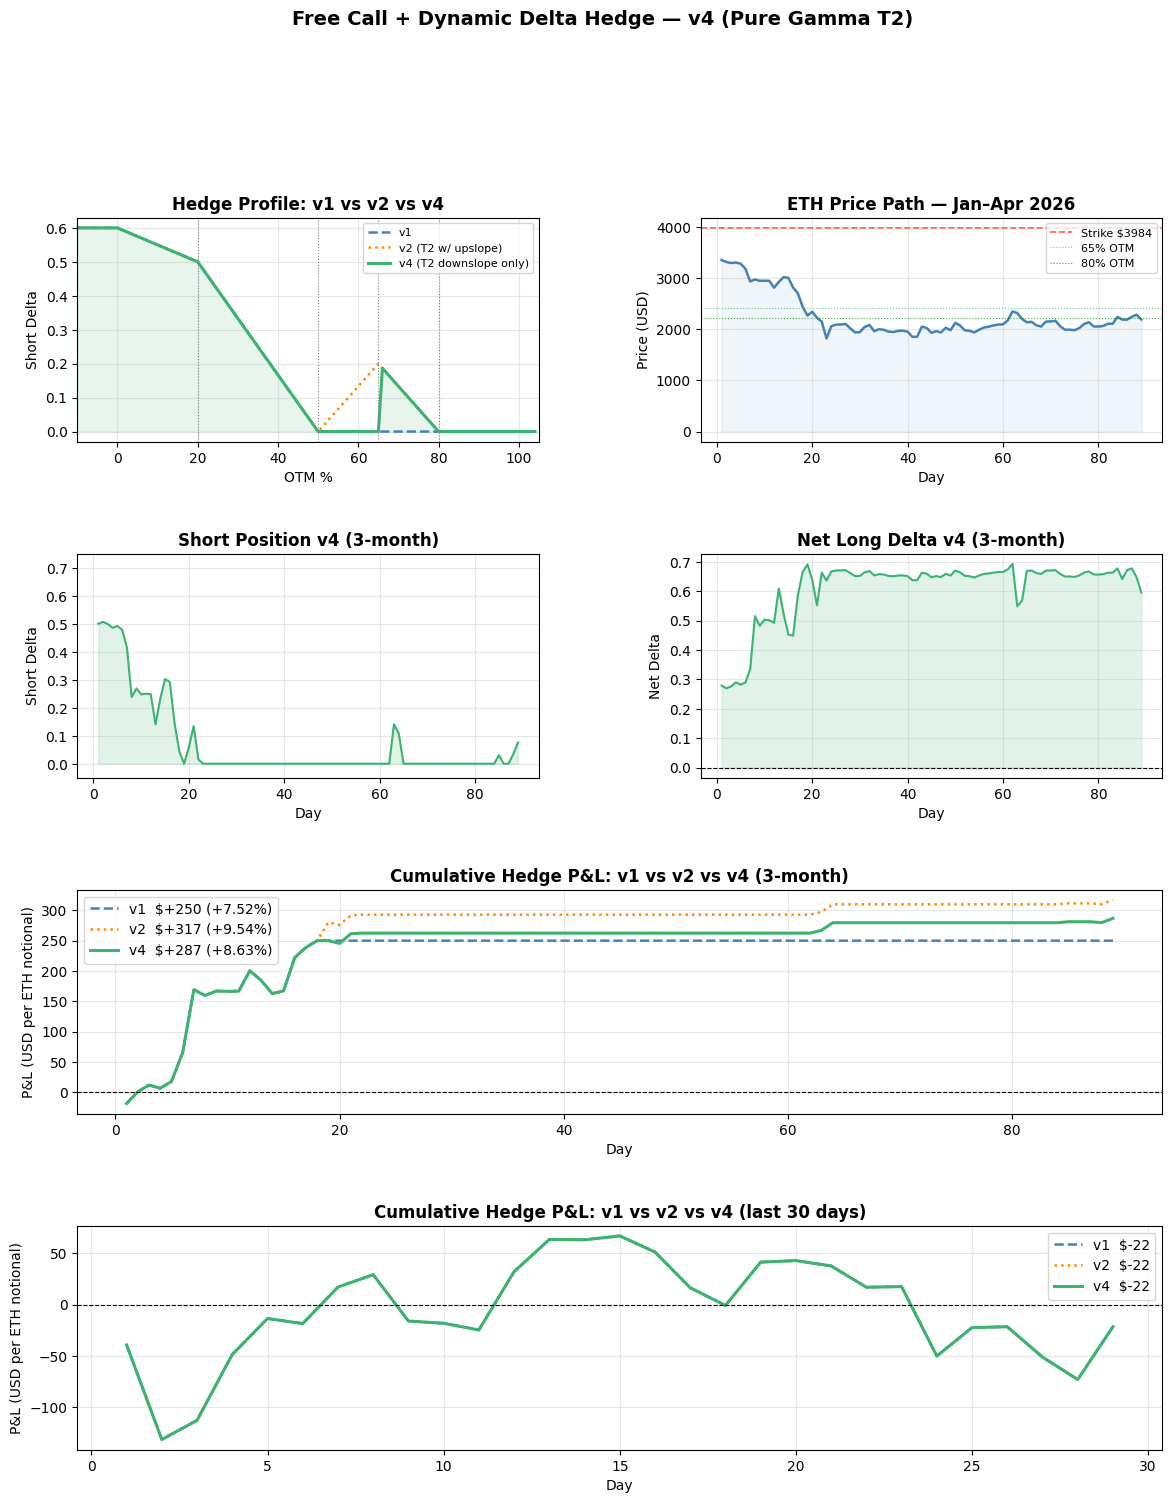

Saved: backtest_results_v4.png


In [4]:
# ── Visualisation ──────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)

days_3m     = [r['day']       for r in rec_v4_3m]
prices_plot = [r['price']     for r in rec_v4_3m]
pnl_v1_3m   = [r['cum_pnl']   for r in rec_v1_3m]
pnl_v2_3m   = [r['cum_pnl']   for r in rec_v2_3m]
pnl_v4_3m   = [r['cum_pnl']   for r in rec_v4_3m]
shorts_v4   = [r['short']     for r in rec_v4_3m]
netd_v4     = [r['net_delta'] for r in rec_v4_3m]
strike_3m   = sum_v4_3m['strike']

# ── 1: Hedge profile comparison ──
ax0 = fig.add_subplot(gs[0, 0])
otm_range = [x / 100 for x in range(-10, 105)]
K_ref     = 3319.935 * 1.20
otm_pcts  = [o * 100 for o in otm_range]

v1_s = [target_short_v1(K_ref / (1 + o), K_ref) for o in otm_range]
v2_s = [target_short_v2(K_ref / (1 + o), K_ref) for o in otm_range]
v4_s = [target_short_v4(K_ref / (1 + o), K_ref) for o in otm_range]

ax0.plot(otm_pcts, v1_s, color='steelblue',    lw=1.8, ls='--', label='v1')
ax0.plot(otm_pcts, v2_s, color='darkorange',   lw=1.8, ls=':',  label='v2 (T2 w/ upslope)')
ax0.plot(otm_pcts, v4_s, color='mediumseagreen', lw=2.2,         label='v4 (T2 downslope only)')
ax0.fill_between(otm_pcts, v4_s, alpha=0.12, color='mediumseagreen')
for x in [20, 50, 65, 80]:
    ax0.axvline(x, color='grey', lw=0.8, ls=':')
ax0.set_xlabel('OTM %')
ax0.set_ylabel('Short Delta')
ax0.set_title('Hedge Profile: v1 vs v2 vs v4', fontweight='bold')
ax0.legend(fontsize=8)
ax0.grid(alpha=0.3)
ax0.set_xlim(-10, 105)

# ── 2: Price path ──
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(days_3m, prices_plot, color='steelblue', lw=1.8)
ax1.axhline(strike_3m, color='tomato', lw=1.2, ls='--', label=f'Strike ${strike_3m:.0f}')
# shade T2 zone
ax1.axhline(strike_3m / 1.65, color='mediumseagreen', lw=0.8, ls=':', alpha=0.7, label='65% OTM')
ax1.axhline(strike_3m / 1.80, color='green',          lw=0.8, ls=':', alpha=0.7, label='80% OTM')
ax1.fill_between(days_3m, prices_plot, alpha=0.08, color='steelblue')
ax1.set_title('ETH Price Path — Jan–Apr 2026', fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.set_xlabel('Day')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# ── 3: Short position v4 ──
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(days_3m, shorts_v4, color='mediumseagreen', lw=1.5)
ax2.fill_between(days_3m, shorts_v4, alpha=0.15, color='mediumseagreen')
ax2.set_title('Short Position v4 (3-month)', fontweight='bold')
ax2.set_ylabel('Short Delta')
ax2.set_xlabel('Day')
ax2.set_ylim(-0.05, 0.75)
ax2.grid(alpha=0.3)

# ── 4: Net delta v4 ──
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(days_3m, netd_v4, color='mediumseagreen', lw=1.5)
ax3.fill_between(days_3m, netd_v4, alpha=0.15, color='mediumseagreen')
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.set_title('Net Long Delta v4 (3-month)', fontweight='bold')
ax3.set_ylabel('Net Delta')
ax3.set_xlabel('Day')
ax3.grid(alpha=0.3)

# ── 5: Cumulative P&L v1 vs v2 vs v4 (3m) ──
ax4 = fig.add_subplot(gs[2, :])
ax4.plot(days_3m, pnl_v1_3m, color='steelblue',      lw=1.8, ls='--', label=f'v1  ${pnl_v1_3m[-1]:+.0f} ({pnl_v1_3m[-1]/prices_3m[0]*100:+.2f}%)')
ax4.plot(days_3m, pnl_v2_3m, color='darkorange',     lw=1.8, ls=':',  label=f'v2  ${pnl_v2_3m[-1]:+.0f} ({pnl_v2_3m[-1]/prices_3m[0]*100:+.2f}%)')
ax4.plot(days_3m, pnl_v4_3m, color='mediumseagreen', lw=2.2,          label=f'v4  ${pnl_v4_3m[-1]:+.0f} ({pnl_v4_3m[-1]/prices_3m[0]*100:+.2f}%)')
ax4.axhline(0, color='black', lw=0.8, ls='--')
ax4.set_title('Cumulative Hedge P&L: v1 vs v2 vs v4 (3-month)', fontweight='bold')
ax4.set_ylabel('P&L (USD per ETH notional)')
ax4.set_xlabel('Day')
ax4.legend()
ax4.grid(alpha=0.3)

# ── 6: 1-month P&L ──
days_1m   = [r['day'] for r in rec_v4_1m]
pnl_v4_1m = [r['cum_pnl'] for r in rec_v4_1m]
rec_v1_1m, _ = run_backtest(prices_1m, target_short_v1)
rec_v2_1m, _ = run_backtest(prices_1m, target_short_v2)
pnl_v1_1m = [r['cum_pnl'] for r in rec_v1_1m]
pnl_v2_1m = [r['cum_pnl'] for r in rec_v2_1m]

ax5 = fig.add_subplot(gs[3, :])
ax5.plot(days_1m, pnl_v1_1m, color='steelblue',      lw=1.8, ls='--', label=f'v1  ${pnl_v1_1m[-1]:+.0f}')
ax5.plot(days_1m, pnl_v2_1m, color='darkorange',     lw=1.8, ls=':',  label=f'v2  ${pnl_v2_1m[-1]:+.0f}')
ax5.plot(days_1m, pnl_v4_1m, color='mediumseagreen', lw=2.2,          label=f'v4  ${pnl_v4_1m[-1]:+.0f}')
ax5.axhline(0, color='black', lw=0.8, ls='--')
ax5.set_title('Cumulative Hedge P&L: v1 vs v2 vs v4 (last 30 days)', fontweight='bold')
ax5.set_ylabel('P&L (USD per ETH notional)')
ax5.set_xlabel('Day')
ax5.legend()
ax5.grid(alpha=0.3)

plt.suptitle('Free Call + Dynamic Delta Hedge — v4 (Pure Gamma T2)', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('backtest_results_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results_v4.png')

In [5]:
# ── Monte Carlo: v1 vs v2 vs v4 ───────────────────────────────────────────────

np.random.seed(42)

MC_N     = 200
MC_S0    = 2000.0
MC_SIGMA = 0.75
MC_MU    = 0.0
MC_DAYS  = 365
MC_DT    = 1.0 / MC_DAYS

def run_path(prices, fn):
    K = prices[0] * 1.20
    cum, short = 0.0, fn(prices[0], K)
    for i in range(1, len(prices)):
        cum += short * (prices[i-1] - prices[i])
        short = fn(prices[i], K)
    return cum + max(0.0, prices[-1] - K)

Z       = np.random.standard_normal((MC_N, MC_DAYS))
log_ret = (MC_MU - 0.5 * MC_SIGMA**2) * MC_DT + MC_SIGMA * math.sqrt(MC_DT) * Z
paths   = MC_S0 * np.exp(np.cumsum(log_ret, axis=1))
paths   = np.hstack([np.full((MC_N, 1), MC_S0), paths])

pnl_v1, pnl_v2, pnl_v4, eth_rets = [], [], [], []
for i in range(MC_N):
    p = paths[i].tolist()
    pnl_v1.append(run_path(p, target_short_v1))
    pnl_v2.append(run_path(p, target_short_v2))
    pnl_v4.append(run_path(p, target_short_v4))
    eth_rets.append((p[-1] / p[0] - 1) * 100)

pnl_v1   = np.array(pnl_v1)
pnl_v2   = np.array(pnl_v2)
pnl_v4   = np.array(pnl_v4)
eth_rets = np.array(eth_rets)
pct_v1   = pnl_v1 / MC_S0 * 100
pct_v2   = pnl_v2 / MC_S0 * 100
pct_v4   = pnl_v4 / MC_S0 * 100

print(f"Monte Carlo  n={MC_N}  S0=${MC_S0:.0f}  sigma={MC_SIGMA}  T=1yr  mu={MC_MU}")
print(f"{'─'*68}")
print(f"{'Metric':30} {'v1':>12} {'v2':>12} {'v4':>12}")
print(f"{'─'*68}")
for label, a, b, c in [
    ("Mean P&L ($)",         pnl_v1.mean(),            pnl_v2.mean(),            pnl_v4.mean()),
    ("Median P&L ($)",       np.median(pnl_v1),        np.median(pnl_v2),        np.median(pnl_v4)),
    ("Std P&L ($)",          pnl_v1.std(),             pnl_v2.std(),             pnl_v4.std()),
    ("Mean P&L (%)",         pct_v1.mean(),            pct_v2.mean(),            pct_v4.mean()),
    ("% paths positive",     (pnl_v1>0).mean()*100,    (pnl_v2>0).mean()*100,    (pnl_v4>0).mean()*100),
    ("% paths > +10%",       (pct_v1>10).mean()*100,   (pct_v2>10).mean()*100,   (pct_v4>10).mean()*100),
    ("% paths < -5%",        (pct_v1<-5).mean()*100,   (pct_v2<-5).mean()*100,   (pct_v4<-5).mean()*100),
    ("Worst P&L ($)",        pnl_v1.min(),             pnl_v2.min(),             pnl_v4.min()),
    ("Best P&L ($)",         pnl_v1.max(),             pnl_v2.max(),             pnl_v4.max()),
    ("5th pctile ($)",       np.percentile(pnl_v1,5),  np.percentile(pnl_v2,5),  np.percentile(pnl_v4,5)),
    ("95th pctile ($)",      np.percentile(pnl_v1,95), np.percentile(pnl_v2,95), np.percentile(pnl_v4,95)),
]:
    print(f"{label:30} {a:>12.2f} {b:>12.2f} {c:>12.2f}")
print(f"{'─'*68}")

Monte Carlo  n=200  S0=$2000  sigma=0.75  T=1yr  mu=0.0
────────────────────────────────────────────────────────────────────
Metric                                   v1           v2           v4
────────────────────────────────────────────────────────────────────
Mean P&L ($)                         440.82       439.60       440.49
Median P&L ($)                       367.02       363.60       353.78
Std P&L ($)                          378.31       371.92       376.75
Mean P&L (%)                          22.04        21.98        22.02
% paths positive                      98.00        98.00        98.00
% paths > +10%                        80.50        83.00        82.50
% paths < -5%                          0.00         0.00         0.00
Worst P&L ($)                        -55.38       -78.55       -63.19
Best P&L ($)                        2770.79      2754.41      2770.79
5th pctile ($)                        50.35        50.35        50.35
95th pctile ($)                     

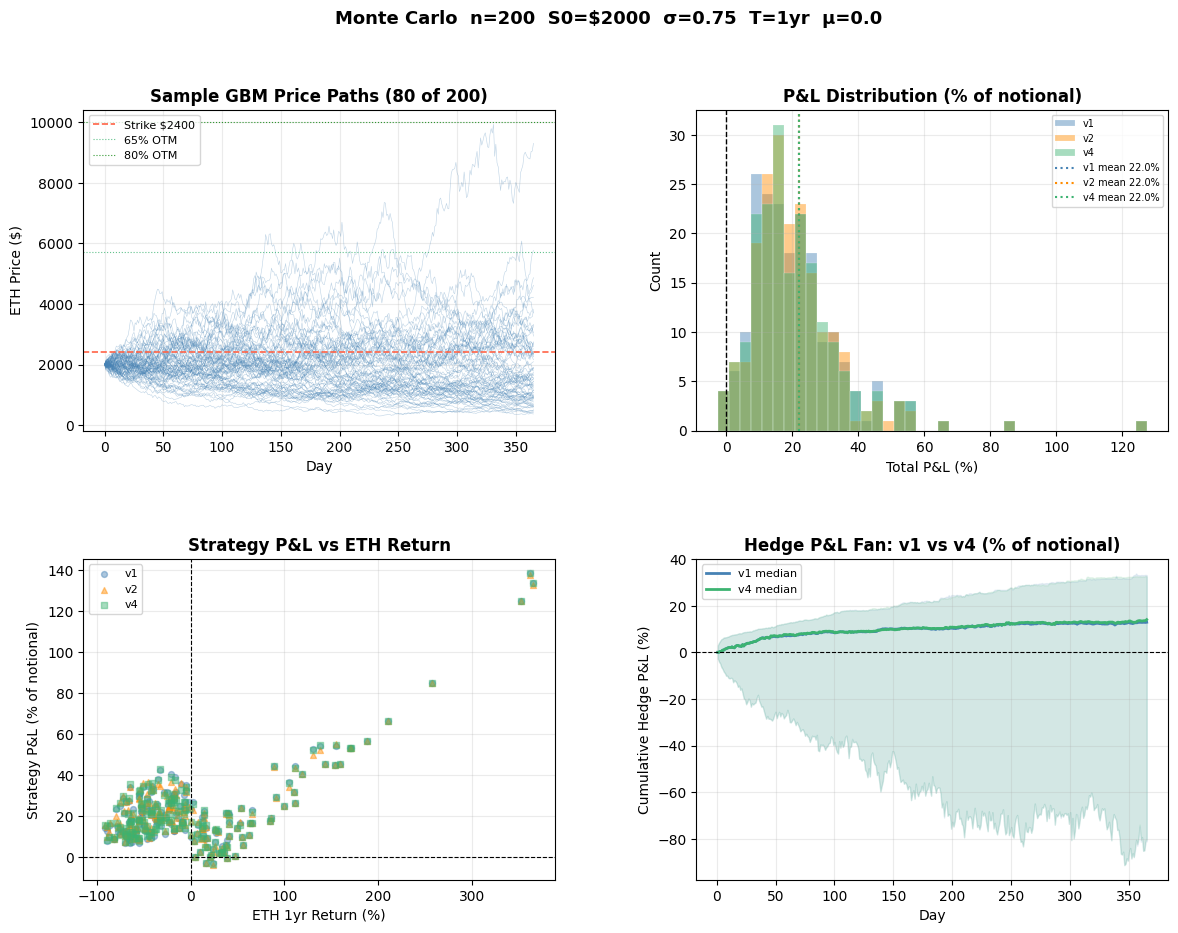

Saved: monte_carlo_v4.png


In [6]:
# ── Monte Carlo Visualisation ──────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Monte Carlo  n={MC_N}  S0=${MC_S0:.0f}  σ={MC_SIGMA}  T=1yr  μ={MC_MU}',
             fontsize=13, fontweight='bold')
plt.subplots_adjust(hspace=0.40, wspace=0.30)

days_mc = np.arange(MC_DAYS + 1)

# ── 1: Sample paths ──
ax = axes[0, 0]
for i in range(min(80, MC_N)):
    ax.plot(days_mc, paths[i], lw=0.4, alpha=0.35, color='steelblue')
ax.axhline(MC_S0 * 1.20, color='tomato',        lw=1.2, ls='--', label=f'Strike ${MC_S0*1.2:.0f}')
ax.axhline(MC_S0 / 0.35, color='mediumseagreen', lw=0.8, ls=':',  alpha=0.8, label='65% OTM')
ax.axhline(MC_S0 / 0.20, color='green',          lw=0.8, ls=':',  alpha=0.8, label='80% OTM')
ax.set_title('Sample GBM Price Paths (80 of 200)', fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('ETH Price ($)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# ── 2: P&L distribution ──
ax = axes[0, 1]
all_pcts = np.concatenate([pct_v1, pct_v2, pct_v4])
bins = np.linspace(np.percentile(all_pcts, 1) - 2, min(np.percentile(all_pcts, 99), 150) + 2, 40)
ax.hist(pct_v1, bins=bins, alpha=0.45, color='steelblue',      label='v1', edgecolor='white', lw=0.3)
ax.hist(pct_v2, bins=bins, alpha=0.45, color='darkorange',     label='v2', edgecolor='white', lw=0.3)
ax.hist(pct_v4, bins=bins, alpha=0.45, color='mediumseagreen', label='v4', edgecolor='white', lw=0.3)
ax.axvline(0,            color='black',          lw=1.0, ls='--')
ax.axvline(pct_v1.mean(), color='steelblue',      lw=1.5, ls=':', label=f'v1 mean {pct_v1.mean():.1f}%')
ax.axvline(pct_v2.mean(), color='darkorange',     lw=1.5, ls=':', label=f'v2 mean {pct_v2.mean():.1f}%')
ax.axvline(pct_v4.mean(), color='mediumseagreen', lw=1.5, ls=':', label=f'v4 mean {pct_v4.mean():.1f}%')
ax.set_title('P&L Distribution (% of notional)', fontweight='bold')
ax.set_xlabel('Total P&L (%)')
ax.set_ylabel('Count')
ax.legend(fontsize=7)
ax.grid(alpha=0.25)

# ── 3: P&L vs ETH return ──
ax = axes[1, 0]
ax.scatter(eth_rets, pct_v1, alpha=0.45, s=18, color='steelblue',      label='v1')
ax.scatter(eth_rets, pct_v2, alpha=0.45, s=18, color='darkorange',     label='v2', marker='^')
ax.scatter(eth_rets, pct_v4, alpha=0.45, s=18, color='mediumseagreen', label='v4', marker='s')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('Strategy P&L vs ETH Return', fontweight='bold')
ax.set_xlabel('ETH 1yr Return (%)')
ax.set_ylabel('Strategy P&L (% of notional)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# ── 4: Hedge P&L fan — v1 vs v4 ──
ax = axes[1, 1]
running_v1 = np.zeros((MC_N, MC_DAYS))
running_v4 = np.zeros((MC_N, MC_DAYS))
for i in range(MC_N):
    p = paths[i].tolist()
    K = p[0] * 1.20
    c1, s1 = 0.0, target_short_v1(p[0], K)
    c4, s4 = 0.0, target_short_v4(p[0], K)
    for d in range(MC_DAYS):
        c1 += s1 * (p[d] - p[d+1]); running_v1[i, d] = c1 / MC_S0 * 100
        c4 += s4 * (p[d] - p[d+1]); running_v4[i, d] = c4 / MC_S0 * 100
        s1 = target_short_v1(p[d+1], K)
        s4 = target_short_v4(p[d+1], K)

d_axis = np.arange(1, MC_DAYS + 1)
for arr, color, label in [
    (running_v1, 'steelblue',      'v1'),
    (running_v4, 'mediumseagreen', 'v4'),
]:
    p5  = np.percentile(arr, 5,  axis=0)
    p50 = np.percentile(arr, 50, axis=0)
    p95 = np.percentile(arr, 95, axis=0)
    ax.fill_between(d_axis, p5, p95, alpha=0.12, color=color)
    ax.plot(d_axis, p50, color=color, lw=2, label=f'{label} median')

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Hedge P&L Fan: v1 vs v4 (% of notional)', fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Cumulative Hedge P&L (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

plt.savefig('monte_carlo_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: monte_carlo_v4.png')